In [1]:

from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'artifacts' / 'preprocess').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root with artifacts/preprocess')


ROOT = find_project_root()
ARTIFACTS = ROOT / 'artifacts' / 'preprocess'
FIGURES = ARTIFACTS / 'figures'

config = json.loads((ARTIFACTS / 'preprocess_config.json').read_text())
target_labels = json.loads((ARTIFACTS / 'target_labels.json').read_text())['target_labels']
manifest_all = pd.read_csv(ARTIFACTS / 'manifest_all.csv')
manifest_filtered = pd.read_csv(ARTIFACTS / 'manifest_filtered.csv')
split_manifest = pd.read_csv(ARTIFACTS / 'split_manifest.csv')
audit = json.loads((ARTIFACTS / 'split_audit.json').read_text())

split_order = ['train', 'val', 'test']
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})


## Dataset Integrity

Check that the manifest was built from the expected CSV/image inventory. This uses the audit summary created during preprocessing.

In [2]:

integrity = pd.Series(audit['integrity_summary'], name='value').rename_axis('metric').reset_index()
display(integrity)


,metric,value
0,rows_csv,5606
1,cols_csv,11
2,unique_images_csv,5606
3,images_on_disk,5606
4,missing_values_total,0
5,duplicated_rows,0
6,csv_images_not_in_disk,0
7,disk_images_not_in_csv,0


## Target Scope

The target order below is the exact multi-hot order expected by later training code.

In [3]:

target_scope = pd.DataFrame({'index': range(len(target_labels)), 'target_label': target_labels})
display(target_scope)


,index,target_label
0,0,No Finding
1,1,Infiltration
2,2,Effusion
3,3,Atelectasis
4,4,Nodule
5,5,Mass


## Filtering Funnel

This shows how many rows remain after selecting `No Finding` plus the five selected disease labels.

,stage,rows
0,all rows,5606
1,retained rows,5101
2,dropped out-of-scope-only rows,505


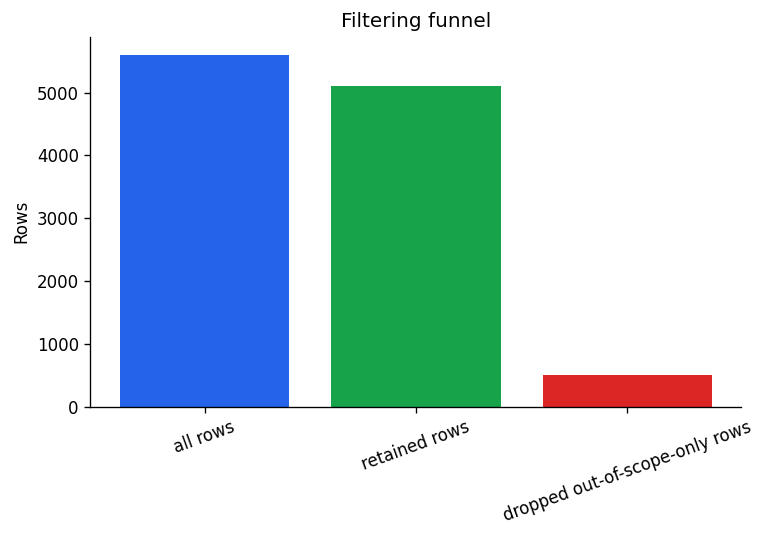

In [4]:

funnel = pd.DataFrame([
    {'stage': 'all rows', 'rows': len(manifest_all)},
    {'stage': 'retained rows', 'rows': len(manifest_filtered)},
    {'stage': 'dropped out-of-scope-only rows', 'rows': len(manifest_all) - len(manifest_filtered)},
])
display(funnel)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(funnel['stage'], funnel['rows'], color=['#2563eb', '#16a34a', '#dc2626'])
ax.set_title('Filtering funnel')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=20)
plt.show()


## Retained Rows with Out-of-Scope Co-labels

These rows are kept because at least one selected target label is present, even though another out-of-scope label also appears.

In [5]:

retained_examples = manifest_filtered.loc[manifest_filtered['has_out_of_scope_label'].astype(bool), [
    'Image Index', 'Patient ID', 'Finding Labels', 'out_of_scope_labels', *target_labels
]].head(8)
display(retained_examples)


,Image Index,Patient ID,Finding Labels,out_of_scope_labels,No Finding,Infiltration,Effusion,Atelectasis,Nodule,Mass
0,00000013_005.png,13,Emphysema|Infiltration|Pleural_Thickening|Pneu...,"[""Emphysema"", ""Pleural_Thickening"", ""Pneumotho...",0,1,0,0,0,0
3,00000032_001.png,32,Cardiomegaly|Edema|Effusion,"[""Cardiomegaly"", ""Edema""]",0,0,1,0,0,0
4,00000040_003.png,40,Consolidation|Mass,"[""Consolidation""]",0,0,0,0,0,1
9,00000061_025.png,61,Consolidation|Effusion|Infiltration|Nodule,"[""Consolidation""]",0,1,1,0,1,0
17,00000103_001.png,103,Mass|Pneumothorax,"[""Pneumothorax""]",0,0,0,0,0,1
34,00000246_016.png,246,Consolidation|Mass,"[""Consolidation""]",0,0,0,0,0,1
36,00000248_020.png,248,Atelectasis|Infiltration|Mass|Pleural_Thickening,"[""Pleural_Thickening""]",0,1,0,1,0,1
54,00000376_007.png,376,Emphysema|Mass,"[""Emphysema""]",0,0,0,0,0,1


## Dropped Out-of-Scope-Only Rows

These rows are dropped because none of the selected target labels is present. They are not converted into `No Finding`.

In [6]:

dropped_examples = manifest_all.loc[~manifest_all['keep_for_mvp'].astype(bool), [
    'Image Index', 'Patient ID', 'Finding Labels', 'out_of_scope_labels', *target_labels
]].head(8)
display(dropped_examples)


,Image Index,Patient ID,Finding Labels,out_of_scope_labels,No Finding,Infiltration,Effusion,Atelectasis,Nodule,Mass
1,00000013_026.png,13,Cardiomegaly|Emphysema,"[""Cardiomegaly"", ""Emphysema""]",0,0,0,0,0,0
19,00000116_013.png,116,Cardiomegaly|Consolidation,"[""Cardiomegaly"", ""Consolidation""]",0,0,0,0,0,0
20,00000116_019.png,116,Consolidation,"[""Consolidation""]",0,0,0,0,0,0
21,00000116_032.png,116,Cardiomegaly|Consolidation,"[""Cardiomegaly"", ""Consolidation""]",0,0,0,0,0,0
22,00000116_040.png,116,Cardiomegaly|Consolidation,"[""Cardiomegaly"", ""Consolidation""]",0,0,0,0,0,0
23,00000118_011.png,118,Pneumothorax,"[""Pneumothorax""]",0,0,0,0,0,0
26,00000132_002.png,132,Consolidation|Pleural_Thickening,"[""Consolidation"", ""Pleural_Thickening""]",0,0,0,0,0,0
31,00000181_001.png,181,Fibrosis,"[""Fibrosis""]",0,0,0,0,0,0


## Target Counts After Filtering

Positive counts confirm the retained MVP label distribution.

,target,positive_rows
0,No Finding,3044
1,Infiltration,967
2,Effusion,644
3,Atelectasis,508
4,Nodule,313
5,Mass,284


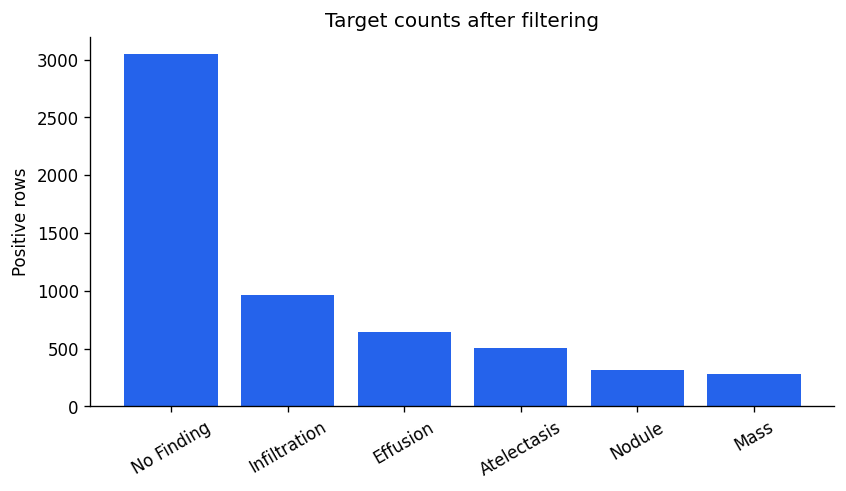

In [7]:

target_counts = manifest_filtered[target_labels].sum().astype(int).sort_values(ascending=False)
display(target_counts.rename('positive_rows').reset_index().rename(columns={'index': 'target'}))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(target_counts.index, target_counts.values, color='#2563eb')
ax.set_title('Target counts after filtering')
ax.set_ylabel('Positive rows')
ax.tick_params(axis='x', rotation=30)
plt.show()


## Split Size Summary

The split is patient-wise, so both row counts and patient counts are checked.

,rows,patients
train,3565,2769
val,756,593
test,780,595


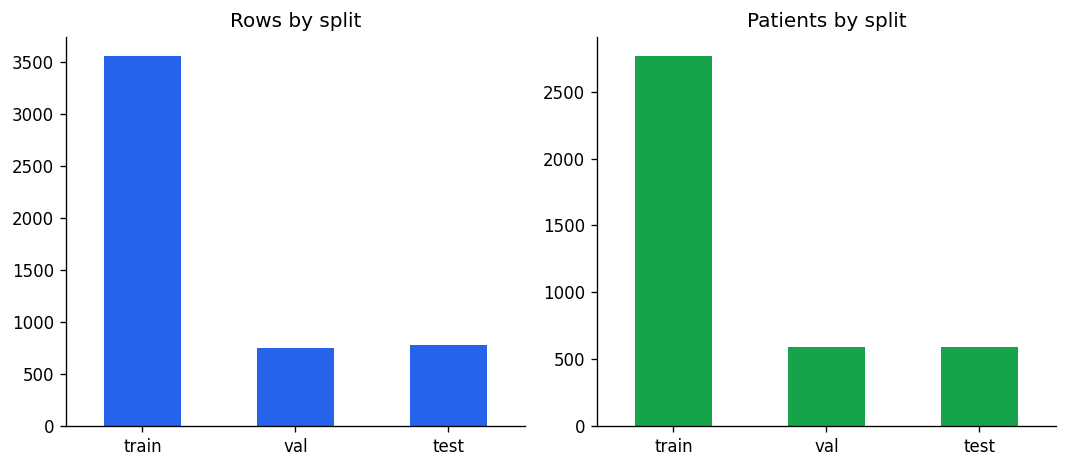

In [8]:

split_counts = pd.DataFrame({
    'rows': pd.Series(audit['rows_per_split']),
    'patients': pd.Series(audit['patients_per_split']),
}).reindex(split_order)
display(split_counts)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
split_counts['rows'].plot(kind='bar', ax=axes[0], color='#2563eb', title='Rows by split')
split_counts['patients'].plot(kind='bar', ax=axes[1], color='#16a34a', title='Patients by split')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Patient Overlap Matrix

Off-diagonal values must be zero to avoid patient leakage.

,train,val,test
train,2769,0,0
val,0,593,0
test,0,0,595


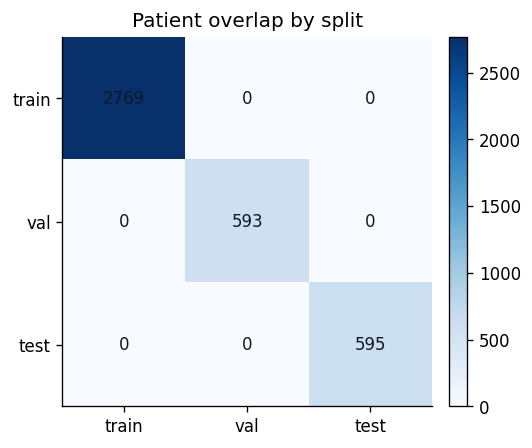

In [9]:

overlap = pd.DataFrame(audit['patient_overlap_matrix']).reindex(index=split_order, columns=split_order)
display(overlap)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(overlap.values, cmap='Blues')
ax.set_xticks(range(len(split_order)), split_order)
ax.set_yticks(range(len(split_order)), split_order)
for i in range(len(split_order)):
    for j in range(len(split_order)):
        ax.text(j, i, int(overlap.iloc[i, j]), ha='center', va='center', color='#111827')
ax.set_title('Patient overlap by split')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## Target Distribution by Split

Counts and prevalence make label coverage and drift visible without optimizing the split with advanced stratification.

,No Finding,Infiltration,Effusion,Atelectasis,Nodule,Mass
train,2128,659,474,364,221,199
val,437,164,82,67,45,52
test,479,144,88,77,47,33


,No Finding,Infiltration,Effusion,Atelectasis,Nodule,Mass
train,59.69,18.49,13.30,10.21,6.20,5.58
val,57.80,21.69,10.85,8.86,5.95,6.88
test,61.41,18.46,11.28,9.87,6.03,4.23


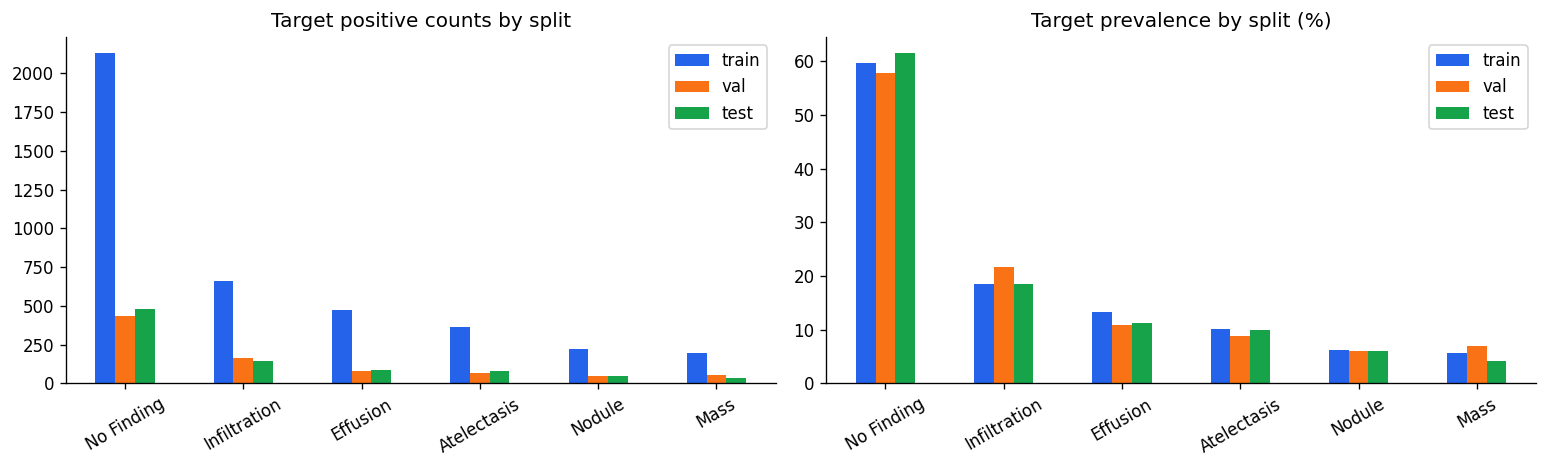

In [10]:

counts_by_split = pd.DataFrame(audit['positive_count_per_target_per_split']).reindex(split_order)
prev_by_split = pd.DataFrame(audit['prevalence_per_target_per_split']).reindex(split_order) * 100
display(counts_by_split)
display(prev_by_split.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts_by_split.T.plot(kind='bar', ax=axes[0], color=['#2563eb', '#f97316', '#16a34a'])
prev_by_split.T.plot(kind='bar', ax=axes[1], color=['#2563eb', '#f97316', '#16a34a'])
axes[0].set_title('Target positive counts by split')
axes[1].set_title('Target prevalence by split (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## AP/PA View Distribution by Split

,train,val,test
AP,1403,273,309
PA,2162,483,471


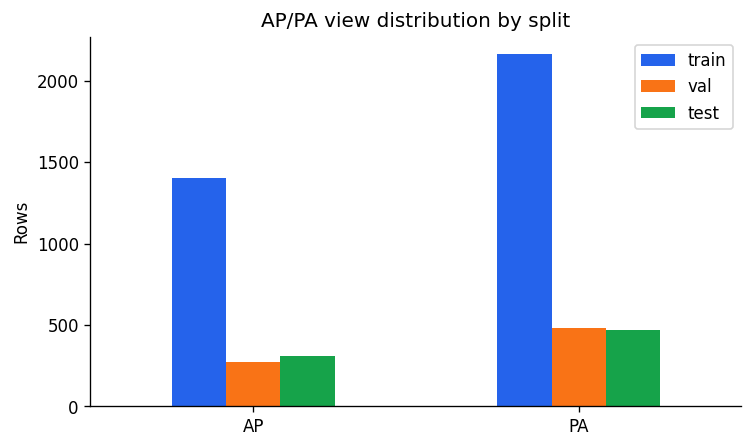

In [11]:

view_dist = (
    pd.DataFrame(audit['view_distribution_per_split'])
    .reindex(columns=split_order)
    .fillna(0)
    .astype(int)
)
display(view_dist)
view_dist.plot(kind='bar', figsize=(7, 4), color=['#2563eb', '#f97316', '#16a34a'], title='AP/PA view distribution by split')
plt.ylabel('Rows')
plt.xticks(rotation=0)
plt.show()


## Gender Distribution by Split

,train,val,test
F,1541,325,347
M,2024,431,433


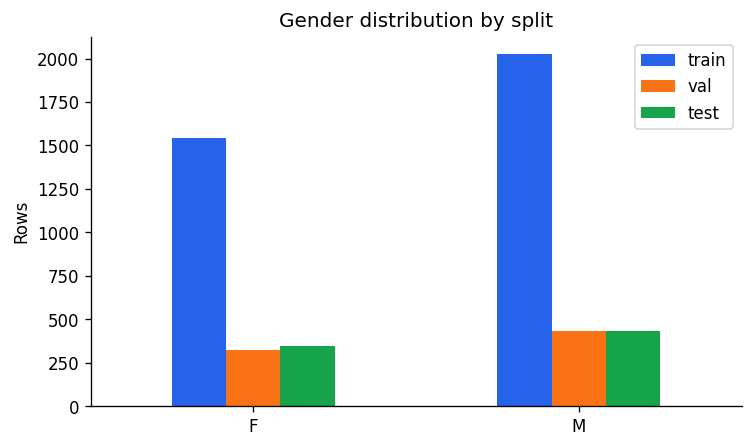

In [12]:

gender_dist = (
    pd.DataFrame(audit['gender_distribution_per_split'])
    .reindex(columns=split_order)
    .fillna(0)
    .astype(int)
)
display(gender_dist)
gender_dist.plot(kind='bar', figsize=(7, 4), color=['#2563eb', '#f97316', '#16a34a'], title='Gender distribution by split')
plt.ylabel('Rows')
plt.xticks(rotation=0)
plt.show()


## Age-Bin Distribution by Split

,train,val,test
0-18,194,51,54
19-40,987,239,225
41-60,1631,303,348
61-80,722,154,145
81-150,30,9,8
150+,1,0,0


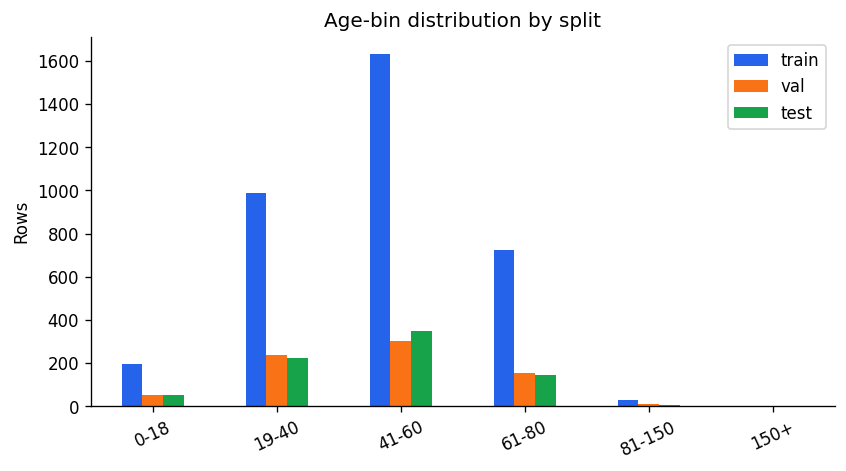

In [13]:

age_dist = (
    pd.DataFrame(audit['age_bin_distribution_per_split'])
    .reindex(columns=split_order)
    .fillna(0)
    .astype(int)
)
display(age_dist)
age_dist.plot(kind='bar', figsize=(8, 4), color=['#2563eb', '#f97316', '#16a34a'], title='Age-bin distribution by split')
plt.ylabel('Rows')
plt.xticks(rotation=25)
plt.show()


## Number of Labels per Image by Split

,train,val,test
1,2903,625,657
2,461,88,82
3,149,28,30
4,37,13,8
5,12,2,3
6,2,0,0
7,1,0,0


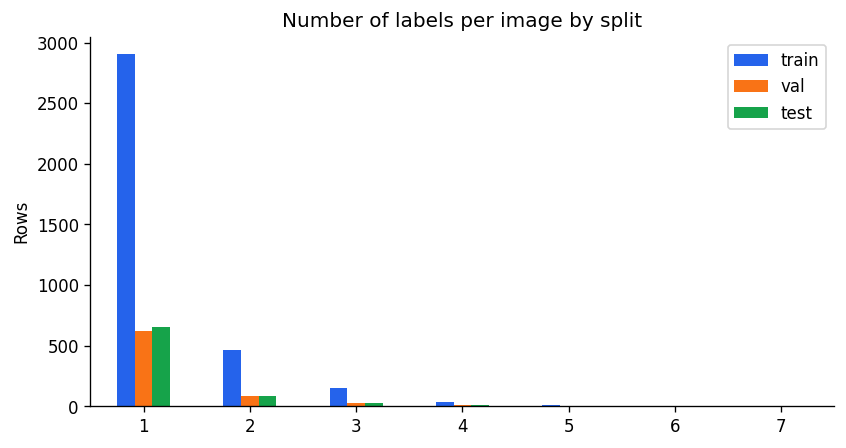

In [14]:

label_count_dist = (
    pd.DataFrame(audit['num_labels_distribution_per_split'])
    .reindex(columns=split_order)
    .fillna(0)
    .astype(int)
    .sort_index()
)
display(label_count_dist)
label_count_dist.plot(kind='bar', figsize=(8, 4), color=['#2563eb', '#f97316', '#16a34a'], title='Number of labels per image by split')
plt.ylabel('Rows')
plt.xticks(rotation=0)
plt.show()


## Number of Images per Patient by Split

,train,val,test
1,2209,477,458
2,684,146,164
3,276,37,83
4,151,27,30
5,97,33,8
6,80,17,7
7,30,19,21
8,14,0,0
9,16,0,9
11,8,0,0


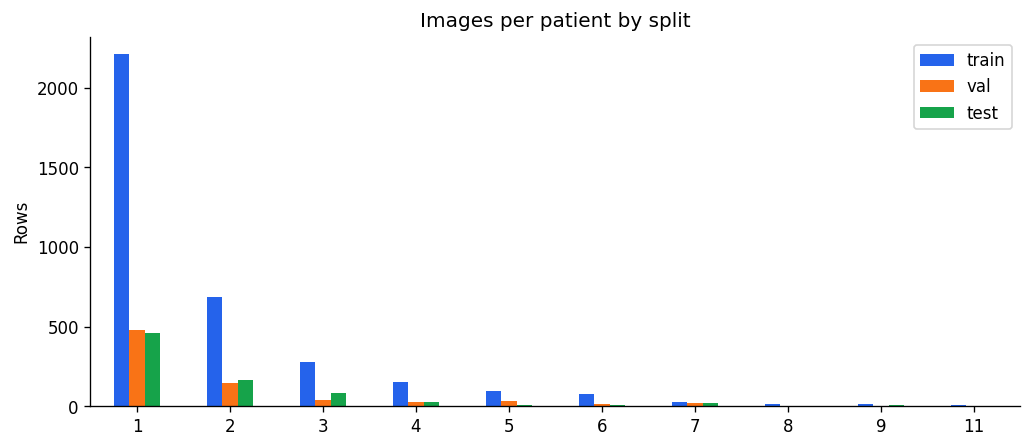

In [15]:

images_per_patient_dist = (
    pd.DataFrame(audit['num_images_per_patient_distribution_per_split'])
    .reindex(columns=split_order)
    .fillna(0)
    .astype(int)
    .sort_index(key=lambda idx: idx.astype(int))
)
display(images_per_patient_dist.head(20))
images_per_patient_dist.head(20).plot(kind='bar', figsize=(10, 4), color=['#2563eb', '#f97316', '#16a34a'], title='Images per patient by split')
plt.ylabel('Rows')
plt.xticks(rotation=0)
plt.show()


## Readiness Checklist

These are the machine-readable outputs that later training code should consume.

In [16]:

checklist_paths = [
    ARTIFACTS / 'preprocess_config.json',
    ARTIFACTS / 'target_labels.json',
    ARTIFACTS / 'manifest_all.csv',
    ARTIFACTS / 'manifest_filtered.csv',
    ARTIFACTS / 'split_manifest.csv',
    ARTIFACTS / 'split_audit.json',
    FIGURES / 'split_label_counts.png',
    FIGURES / 'split_label_prevalence.png',
    FIGURES / 'split_view_distribution.png',
    FIGURES / 'split_gender_distribution.png',
    FIGURES / 'split_age_distribution.png',
]
checklist = pd.DataFrame({
    'artifact': [str(path.relative_to(ROOT)) for path in checklist_paths],
    'exists': [path.exists() for path in checklist_paths],
})
summary = pd.DataFrame([
    {'check': 'filtered rows', 'value': len(manifest_filtered), 'expected': 5101, 'pass': len(manifest_filtered) == 5101},
    {'check': 'patient overlap off diagonal', 'value': int(overlap.values.sum() - overlap.values.diagonal().sum()), 'expected': 0, 'pass': int(overlap.values.sum() - overlap.values.diagonal().sum()) == 0},
    {'check': 'all target columns present', 'value': set(target_labels).issubset(split_manifest.columns), 'expected': True, 'pass': set(target_labels).issubset(split_manifest.columns)},
])
display(checklist)
display(summary)


,artifact,exists
0,artifacts/preprocess/preprocess_config.json,True
1,artifacts/preprocess/target_labels.json,True
2,artifacts/preprocess/manifest_all.csv,True
3,artifacts/preprocess/manifest_filtered.csv,True
4,artifacts/preprocess/split_manifest.csv,True
5,artifacts/preprocess/split_audit.json,True
6,artifacts/preprocess/figures/split_label_count...,True
7,artifacts/preprocess/figures/split_label_preva...,True
8,artifacts/preprocess/figures/split_view_distri...,True
9,artifacts/preprocess/figures/split_gender_dist...,True


,check,value,expected,pass
0,filtered rows,5101,5101,True
1,patient overlap off diagonal,0,0,True
2,all target columns present,True,True,True
